# Emotion classification using the RAVDESS dataset

The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS) is licensed under CC BY-NA-SC 4.0. and can be downloaded free of charge at https://zenodo.org/record/1188976.

***Construction and Validation***

Construction and validation of the RAVDESS is described in our paper: Livingstone SR, Russo FA (2018) The Ryerson Audio-Visual Database of Emotional Speech and Song (RAVDESS): A dynamic, multimodal set of facial and vocal expressions in North American English. PLoS ONE 13(5): e0196391. https://doi.org/10.1371/journal.pone.0196391.

The RAVDESS contains 7356 files. Each file was rated 10 times on emotional validity, intensity, and genuineness. Ratings were provided by 247 individuals who were characteristic of untrained adult research participants from North America. A further set of 72 participants provided test-retest data. High levels of emotional validity, interrater reliability, and test-retest intrarater reliability were reported. Validation data is open-access, and can be downloaded along with our paper from PLOS ONE.

***Description***

The dataset contains the complete set of 7356 RAVDESS files (total size: 24.8 GB). Each of the 24 actors consists of three modality formats: Audio-only (16bit, 48kHz .wav), Audio-Video (720p H.264, AAC 48kHz, .mp4), and Video-only (no sound).  Note, there are no song files for Actor_18.

***Data***

For this task, I have used 4948 samples from the RAVDESS dataset.

The samples comes from:

- Audio-only files;
- Video + audio files: I have extracted the audio from each file using the script Mp4ToWav.py that you can find in the main directory of the project.

***License information***

The RAVDESS is released under a Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License, CC BY-NA-SC 4.0

***File naming convention***

Each of the 7356 RAVDESS files has a unique filename. The filename consists of a 7-part numerical identifier (e.g., 02-01-06-01-02-01-12.mp4). These identifiers define the stimulus characteristics:

***Filename identifiers***

- Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
- Vocal channel (01 = speech, 02 = song).
- Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
- Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the ‘neutral’ emotion.
- Statement (01 = “Kids are talking by the door”, 02 = “Dogs are sitting by the door”).
- Repetition (01 = 1st repetition, 02 = 2nd repetition).
- Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Filename example: 02-01-06-01-02-01-12.mp4

- Video-only (02)
- Speech (01)
- Fearful (06)
- Normal intensity (01)
- Statement “dogs” (02)
- 1st Repetition (01)
- 12th Actor (12)
- Female, as the actor ID number is even.

# Analysis

We are using Colab, a Google Cloud environment for jupyter, so we need to import our files from Google Drive and then install LibROSA, a python package for music and audio analysis.

After the import, we will plot the signal of the first file.

In [2]:
# Cell 1: Import libraries and mount Google Drive
import os
import numpy as np
import pandas as pd
import librosa
from librosa import display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# For neural network
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv1D, MaxPooling1D
from keras.callbacks import ModelCheckpoint

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
!pip install librosa

In [6]:
# Cell 2: Set up paths and verify dataset
# Configuration
DATASET_PATH = '/content/drive/My Drive/Ravdess/Audio_Speech_Actors_01-24'
MODEL_SAVE_PATH = '/content/drive/My Drive/Ravdess_model'
MODEL_NAME = 'Emotion_Voice_Detection_Model.h5'

# Verify dataset path exists
if os.path.exists(DATASET_PATH):
    print(f"✓ Dataset path found: {DATASET_PATH}")
    # List first few actors
    actors = [d for d in os.listdir(DATASET_PATH) if d.startswith('Actor_')]
    print(f"✓ Found {len(actors)} actor folders")
    print(f"  First few actors: {actors[:5]}")
else:
    print(f"✗ Dataset path NOT found: {DATASET_PATH}")
    print("  Please check your Google Drive folder structure")

# Emotion mapping based on RAVDESS naming convention
EMOTIONS = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

print("\nEmotion mapping:")
for code, emotion in EMOTIONS.items():
    print(f"  {code}: {emotion}")

✓ Dataset path found: /content/drive/My Drive/Ravdess/Audio_Speech_Actors_01-24
✓ Found 24 actor folders
  First few actors: ['Actor_22', 'Actor_24', 'Actor_17', 'Actor_23', 'Actor_16']

Emotion mapping:
  01: neutral
  02: calm
  03: happy
  04: sad
  05: angry
  06: fearful
  07: disgust
  08: surprised


Loading sample file: /content/drive/My Drive/Ravdess/Audio_Speech_Actors_01-24/Actor_22/03-01-06-01-01-02-22.wav


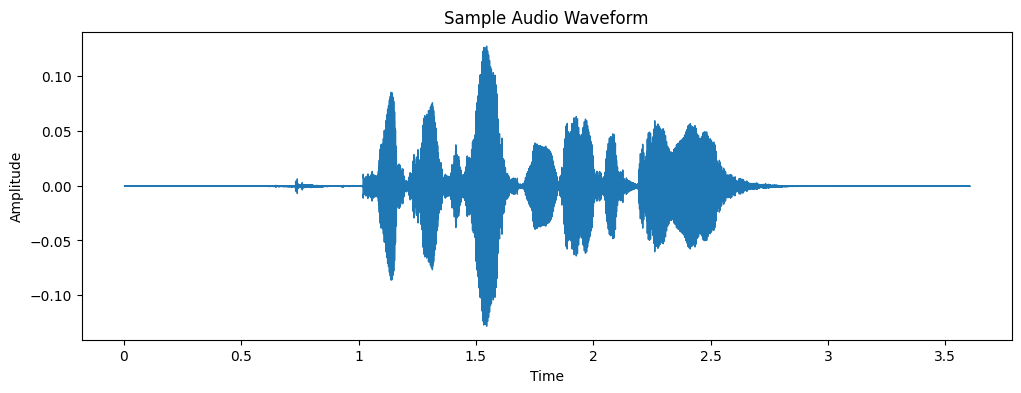

Sample rate: 22050 Hz
Duration: 3.60 seconds


In [7]:
# ============================================================================
# Cell 3: Plot a sample audio file
# ============================================================================

# Find and plot the first audio file
sample_file = None
for actor_folder in os.listdir(DATASET_PATH):
    actor_path = os.path.join(DATASET_PATH, actor_folder)
    if os.path.isdir(actor_path):
        files = [f for f in os.listdir(actor_path) if f.endswith('.wav')]
        if files:
            sample_file = os.path.join(actor_path, files[0])
            break

if sample_file:
    print(f"Loading sample file: {sample_file}")
    data, sampling_rate = librosa.load(sample_file)

    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(data, sr=sampling_rate)
    plt.title('Sample Audio Waveform')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')
    plt.show()

    print(f"Sample rate: {sampling_rate} Hz")
    print(f"Duration: {len(data)/sampling_rate:.2f} seconds")
else:
    print("No audio files found in the dataset!")

In [8]:
# Cell 4: Load dataset and extract features
# ============================================================================

def extract_features(file_path, n_mfcc=40):
    try:
        X, sample_rate = librosa.load(file_path)   # removed res_type
        mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=n_mfcc).T, axis=0)
        return mfccs
    except Exception as e:
        print(f"Error loading {file_path}: {str(e)}")
        return None

# Load all files
print("Loading and processing audio files...")
features_list = []
labels_list = []

file_count = 0
error_count = 0

for actor_folder in sorted(os.listdir(DATASET_PATH)):
    actor_path = os.path.join(DATASET_PATH, actor_folder)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):
        if not file.endswith('.wav'):
            continue

        try:
            file_path = os.path.join(actor_path, file)

            # Extract MFCC features
            mfccs = extract_features(file_path)

            if mfccs is not None:
                # Extract emotion code from filename
                # Format: 03-01-06-01-02-01-12.wav
                # Position 3 (index 2) is the emotion
                emotion_code = file.split('-')[2]

                features_list.append(mfccs)
                labels_list.append(emotion_code)
                file_count += 1

                if file_count % 200 == 0:
                    print(f"  Processed {file_count} files...")
            else:
                error_count += 1

        except Exception as e:
            print(f"Error processing {file}: {str(e)}")
            error_count += 1
            continue

print(f"\n✓ Dataset loading complete!")
print(f"  Successfully processed: {file_count} files")
print(f"  Errors encountered: {error_count} files")

# Convert to numpy arrays
X = np.array(features_list)
y = np.array(labels_list)

print(f"\nDataset shape:")
print(f"  Features (X): {X.shape}")
print(f"  Labels (y): {y.shape}")

# Show distribution of emotions
print(f"\nEmotion distribution:")
unique, counts = np.unique(y, return_counts=True)
for emotion_code, count in zip(unique, counts):
    emotion_name = EMOTIONS.get(emotion_code, 'unknown')
    print(f"  {emotion_code} ({emotion_name}): {count} samples")

Loading and processing audio files...
  Processed 200 files...
  Processed 400 files...
  Processed 600 files...
  Processed 800 files...
  Processed 1000 files...
  Processed 1200 files...
  Processed 1400 files...

✓ Dataset loading complete!
  Successfully processed: 1440 files
  Errors encountered: 0 files

Dataset shape:
  Features (X): (1440, 40)
  Labels (y): (1440,)

Emotion distribution:
  01 (neutral): 96 samples
  02 (calm): 192 samples
  03 (happy): 192 samples
  04 (sad): 192 samples
  05 (angry): 192 samples
  06 (fearful): 192 samples
  07 (disgust): 192 samples
  08 (surprised): 192 samples


# Load all files

We will create our numpy array extracting Mel-frequency cepstral coefficients (MFCCs), while the classes to predict will be extracted from the name of the file (see the introductory section of this notebook to see the naming convention of the files of this dataset).

In [9]:
import os
import numpy as np
import librosa

data_path = "/content/drive/MyDrive/Ravdess/Audio_Speech_Actors_01-24/Actor_01"
lst = []

for subdir, dirs, files in os.walk(data_path):
    for file in files:
        if file.lower().endswith('.wav'):
            print("Found file:", file)
            file_path = os.path.join(subdir, file)
            try:
                X, sr = librosa.load(file_path, sr=None)
                mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sr, n_mfcc=40).T, axis=0)
                label = file[6:8]
                lst.append([mfccs, label])
            except Exception as e:
                print("Error:", file_path, e)


Found file: 03-01-01-01-01-01-01.wav
Found file: 03-01-05-01-01-02-01.wav
Found file: 03-01-04-02-02-02-01.wav
Found file: 03-01-03-02-01-01-01.wav
Found file: 03-01-01-01-01-02-01.wav
Found file: 03-01-04-01-02-01-01.wav
Found file: 03-01-02-01-01-02-01.wav
Found file: 03-01-03-01-02-01-01.wav
Found file: 03-01-03-02-02-01-01.wav
Found file: 03-01-04-02-01-02-01.wav
Found file: 03-01-02-02-02-01-01.wav
Found file: 03-01-04-02-01-01-01.wav
Found file: 03-01-02-01-02-02-01.wav
Found file: 03-01-03-01-01-02-01.wav
Found file: 03-01-01-01-02-01-01.wav
Found file: 03-01-03-01-01-01-01.wav
Found file: 03-01-04-01-02-02-01.wav
Found file: 03-01-02-02-01-01-01.wav
Found file: 03-01-02-01-02-01-01.wav
Found file: 03-01-02-02-01-02-01.wav
Found file: 03-01-03-02-02-02-01.wav
Found file: 03-01-04-01-01-01-01.wav
Found file: 03-01-02-01-01-01-01.wav
Found file: 03-01-05-01-01-01-01.wav
Found file: 03-01-03-02-01-02-01.wav
Found file: 03-01-05-01-02-01-01.wav
Found file: 03-01-03-01-02-02-01.wav
F

In [10]:
X = np.array([item[0] for item in lst])
y = np.array([item[1] for item in lst])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (60, 40)
y shape: (60,)


# Decision Tree Classifier

To make a first attempt in accomplishing this classification task I chose a decision tree:

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [12]:
print(X.shape)
print(y.shape)

(60, 40)
(60,)


In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
dtree = DecisionTreeClassifier()

In [15]:
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

In [16]:
predictions = dtree.predict(X_test)

Let's go with our classification report.

Before we start, a quick reminder of the classes we are trying to predict:

emotions = {
    "neutral": "01",
    "calm": "02",
    "happy": "03",
    "sad": "04",
    "angry": "05",
    "fearful": "06",
    "disgust": "07",
    "surprised": "08"
}

In [17]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

          01       1.00      0.50      0.67         2
          02       0.75      1.00      0.86         3
          03       0.67      0.67      0.67         3
          04       0.20      1.00      0.33         1
          05       1.00      0.50      0.67         2
          06       1.00      0.40      0.57         5
          07       0.00      0.00      0.00         0
          08       0.00      0.00      0.00         4

    accuracy                           0.50        20
   macro avg       0.58      0.51      0.47        20
weighted avg       0.67      0.50      0.52        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Random Forest

In this second approach, I switched to a random forest classifier and I made a gridsearch to make some hyperparameters tuning.

The gridsearch is not shown in the code below otherwise the notebook will require too much time to run.

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
rforest = RandomForestClassifier(criterion="gini", max_depth=10, max_features="log2",
                                 max_leaf_nodes = 100, min_samples_leaf = 3, min_samples_split = 20,
                                 n_estimators= 22000, random_state= 5)

In [20]:
rforest.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features='log2', max_leaf_nodes=100,
                       min_samples_leaf=3, min_samples_split=20,
                       n_estimators=22000, random_state=5)

In [21]:
predictions = rforest.predict(X_test)

In [22]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

          01       0.00      0.00      0.00         2
          02       0.75      1.00      0.86         3
          03       1.00      0.33      0.50         3
          04       0.11      1.00      0.20         1
          05       0.00      0.00      0.00         2
          06       0.00      0.00      0.00         5
          07       0.00      0.00      0.00         0
          08       0.00      0.00      0.00         4

    accuracy                           0.25        20
   macro avg       0.23      0.29      0.19        20
weighted avg       0.27      0.25      0.21        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# Neural network

Let's build our neural network!

To do so, we need to expand the dimensions of our array, adding a third one using the numpy "expand_dims" feature.

In [23]:
x_traincnn = np.expand_dims(X_train, axis=2)
x_testcnn = np.expand_dims(X_test, axis=2)

In [24]:
x_traincnn.shape, x_testcnn.shape

((40, 40, 1), (20, 40, 1))

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Activation
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder


# ---------------------------
# MODEL
# ---------------------------
model = Sequential()

model.add(Conv1D(128, 5, padding='same', input_shape=(40, 1)))
model.add(Activation('relu'))
model.add(Dropout(0.1))

model.add(MaxPooling1D(pool_size=8))

model.add(Conv1D(128, 5, padding='same'))
model.add(Activation('relu'))
model.add(Dropout(0.1))

model.add(Flatten())  # ONLY ONE FLATTEN

model.add(Dense(8, activation='softmax'))  # 8 emotion classes

# ---------------------------
# OPTIMIZER + COMPILE
# ---------------------------
opt = RMSprop(learning_rate=0.00005, rho=0.9)

model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',   # since we use ONE-HOT
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# ---------------------------
# LABEL ENCODING
# ---------------------------
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)
y_test_int = le.transform(y_test)

# Convert integers → one-hot
y_train_onehot = to_categorical(y_train_int, num_classes=8)
y_test_onehot = to_categorical(y_test_int, num_classes=8)

With *model.summary* we can see a recap of what we have build:

In [27]:
# ---------------------------
# CHECK SHAPES
# ---------------------------
print("x_traincnn:", x_traincnn.shape)
print("y_train_onehot:", y_train_onehot.shape)
print("x_testcnn:", x_testcnn.shape)
print("y_test_onehot:", y_test_onehot.shape)

print(model.summary())

x_traincnn: (40, 40, 1)
y_train_onehot: (40, 8)
x_testcnn: (20, 40, 1)
y_test_onehot: (20, 8)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         5,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,944 (343.53 KB)

 Trainable params: 87,944 (343.53 KB)

 Non-trainable params: 0 (0.00 B)

None


Now we can compile and fit our model:

In [28]:
# ---------------------------
# TRAIN
# ---------------------------
cnnhistory = model.fit(
    x_traincnn,
    y_train_onehot,
    batch_size=16,
    epochs=1000,
    validation_data=(x_testcnn, y_test_onehot)
)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - accuracy: 0.1047 - loss: 18.1587 - val_accuracy: 0.0000e+00 - val_loss: 13.6256
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1656 - loss: 14.2836 - val_accuracy: 0.0000e+00 - val_loss: 9.8546
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1297 - loss: 11.9490 - val_accuracy: 0.1500 - val_loss: 8.2723
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0781 - loss: 11.0810 - val_accuracy: 0.1500 - val_loss: 6.2098
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1250 - loss: 8.1813 - val_accuracy: 0.0000e+00 - val_loss: 5.5148
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.0203 - loss: 10.4006 - val_accuracy: 0.0000e+00 - val_loss: 6.2300
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0688 - loss: 8.1404 - val_accuracy: 0.0000e+00 - val_loss: 5.8268
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0203 - loss: 9.8168

Let's plot the loss:

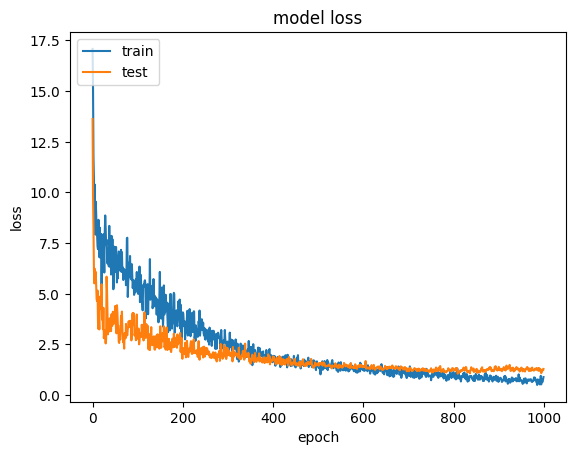

In [29]:
plt.plot(cnnhistory.history['loss'])
plt.plot(cnnhistory.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()



And now let's plot the accuracy:

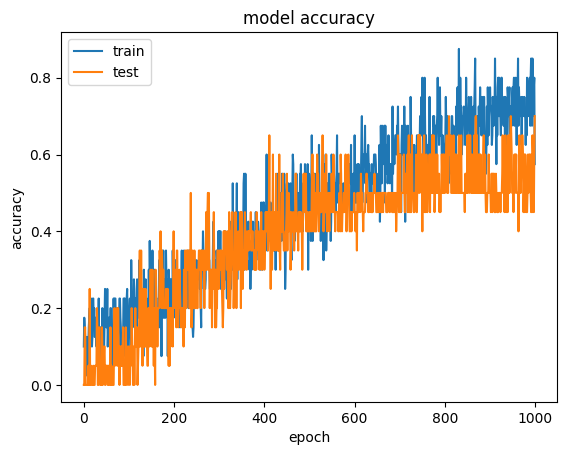

In [30]:
plt.plot(cnnhistory.history['accuracy'])
plt.plot(cnnhistory.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Save the model

In [31]:
model_name = 'Emotion_Voice_Detection_Model.h5'
save_dir = '/content/drive/My Drive/Ravdess_model'
# Save model and weights
if not os.path.isdir(save_dir):
    os.makedirs(save_dir)
model_path = os.path.join(save_dir, model_name)
model.save(model_path)
print('Saved trained model at %s ' % model_path)

Saved trained model at /content/drive/My Drive/Ravdess_model/Emotion_Voice_Detection_Model.h5 


# Reloading the model to test it

In [32]:
loaded_model = keras.models.load_model('/content/drive/My Drive/Ravdess_model/Emotion_Voice_Detection_Model.h5')
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         5,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,946 (343.54 KB)

 Trainable params: 87,944 (343.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

# Checking the accuracy of the loaded model

In [33]:
loss, acc = loaded_model.evaluate(x_testcnn, y_test_onehot)
print("Restored model, accuracy: {:5.2f}%".format(100 * acc))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.7000 - loss: 1.2896
Restored model, accuracy: 70.00%


# Thank you


In [38]:
# after training
model.save('model.h5')   # creates model.h5 in Colab working dir (/content)




In [39]:
from google.colab import files
files.download('model.h5')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>